# Phase 5: Single-Cell Graph Convolutional Network
Train a GCN on the thyrocyte kNN graph to predict tumour stage from each cell and its neighbourhood. Cells are split into train/validation/test sets so accuracy is measured on cells the model never trained on, and a logistic-regression baseline shows what the graph adds.

### Cell 1: Imports & Build the Cell Graph

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, ConfusionMatrixDisplay

torch.manual_seed(42)
np.random.seed(42)
PROCESSED_DIR = os.path.join(os.getcwd(), "processed_data")
STAGES = ["Paratumor", "Primary Tumor", "LN Metastasis", "RAI-Refractory Metastasis"]

adata = sc.read_h5ad(os.path.join(PROCESSED_DIR, "adata_trajectory.h5ad"))

# Symmetric kNN connectivities from Phase 4 -> undirected edges
knn = adata.obsp["connectivities"].tocoo()
edge_index = torch.tensor(np.vstack((knn.row, knn.col)), dtype=torch.long)
x = torch.tensor(adata.obsm["X_pca_harmony"], dtype=torch.float)
labels = adata.obs["tissue_type"].map({s: i for i, s in enumerate(STAGES)}).astype(int).values
y = torch.tensor(labels, dtype=torch.long)
print(f"Nodes: {x.shape[0]} | Edges: {edge_index.shape[1]} | Features: {x.shape[1]}")
print(pd.Series(labels).map(dict(enumerate(STAGES))).value_counts())

C:\Users\omar_\anaconda3\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Nodes: 49419 | Edges: 1155594 | Features: 50
Primary Tumor                20533
LN Metastasis                16723
Paratumor                     6823
RAI-Refractory Metastasis     5340
Name: count, dtype: int64


### Cell 2: Stratified Train / Validation / Test Split (70 / 15 / 15)

In [2]:
idx = np.arange(len(labels))
train_idx, hold_idx = train_test_split(idx, test_size=0.30, stratify=labels, random_state=42)
val_idx, test_idx = train_test_split(hold_idx, test_size=0.50, stratify=labels[hold_idx], random_state=42)

def mask(ix):
    m = torch.zeros(len(labels), dtype=torch.bool)
    m[ix] = True
    return m

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = Data(x=x, edge_index=edge_index, y=y,
            train_mask=mask(train_idx), val_mask=mask(val_idx), test_mask=mask(test_idx)).to(device)

# Class weights counter the small RAI-Refractory group
counts = np.bincount(labels[train_idx], minlength=len(STAGES))
class_weights = torch.tensor(len(train_idx) / (len(STAGES) * counts), dtype=torch.float, device=device)
print("Device:", device, "| train/val/test:", len(train_idx), len(val_idx), len(test_idx))

Device: cpu | train/val/test: 34593 7413 7413


### Cell 3: Define & Train the GCN

Epoch  20 | Loss: 0.7458 | Val balanced acc: 0.693


Epoch  40 | Loss: 0.6548 | Val balanced acc: 0.740


Epoch  60 | Loss: 0.6015 | Val balanced acc: 0.762


Epoch  80 | Loss: 0.5723 | Val balanced acc: 0.774


Epoch 100 | Loss: 0.5538 | Val balanced acc: 0.785


Epoch 120 | Loss: 0.5407 | Val balanced acc: 0.790


Epoch 140 | Loss: 0.5294 | Val balanced acc: 0.794


Epoch 160 | Loss: 0.5219 | Val balanced acc: 0.796


Epoch 180 | Loss: 0.5158 | Val balanced acc: 0.799


Epoch 200 | Loss: 0.5106 | Val balanced acc: 0.799


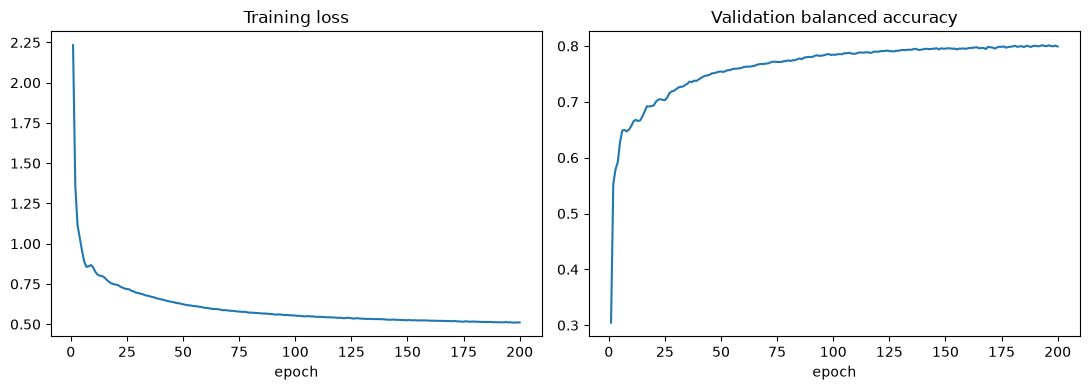

In [3]:
class CellGCN(torch.nn.Module):
    def __init__(self, in_dim=50, hidden=64, n_classes=4):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, n_classes)

    def forward(self, x, edge_index):
        h = F.dropout(F.relu(self.conv1(x, edge_index)), p=0.2, training=self.training)
        return F.log_softmax(self.conv2(h, edge_index), dim=1)

model = CellGCN(in_dim=x.shape[1], n_classes=len(STAGES)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

@torch.no_grad()
def evaluate(m):
    model.eval()
    pred = model(data.x, data.edge_index).argmax(dim=1)
    return balanced_accuracy_score(data.y[m].cpu(), pred[m].cpu())

history, best_val, best_state = [], 0.0, None
for epoch in range(1, 201):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask], weight=class_weights)
    loss.backward()
    optimizer.step()

    val_bacc = evaluate(data.val_mask)
    history.append((epoch, loss.item(), val_bacc))
    if val_bacc > best_val:
        best_val, best_state = val_bacc, {k: v.detach().clone() for k, v in model.state_dict().items()}
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | Val balanced acc: {val_bacc:.3f}")

model.load_state_dict(best_state)
hist = pd.DataFrame(history, columns=["epoch", "loss", "val_bacc"])
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
hist.plot(x="epoch", y="loss", ax=ax[0], legend=False, title="Training loss")
hist.plot(x="epoch", y="val_bacc", ax=ax[1], legend=False, title="Validation balanced accuracy")
plt.tight_layout()
plt.show()

### Cell 4: Test-Set Evaluation vs. Non-Graph Baseline

                                accuracy  balanced_accuracy
GCN (graph)                        0.761              0.803
Logistic regression (no graph)     0.612              0.665

GCN test-set report:
                           precision    recall  f1-score   support

                Paratumor      0.811     0.962     0.880      1023
            Primary Tumor      0.838     0.715     0.772      3080
            LN Metastasis      0.777     0.719     0.747      2509
RAI-Refractory Metastasis      0.521     0.815     0.636       801

                 accuracy                          0.761      7413
                macro avg      0.737     0.803     0.759      7413
             weighted avg      0.780     0.761     0.764      7413



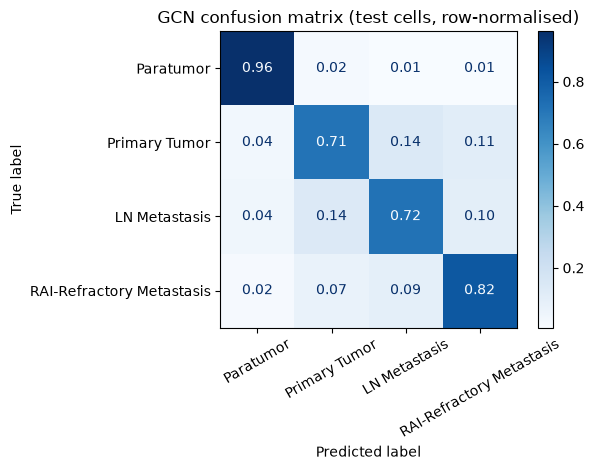

In [4]:
model.eval()
with torch.no_grad():
    gcn_pred = model(data.x, data.edge_index).argmax(dim=1).cpu().numpy()

# Baseline: same features, no graph
lr = LogisticRegression(max_iter=2000, class_weight="balanced")
lr.fit(x[train_idx].numpy(), labels[train_idx])
lr_pred = lr.predict(x[test_idx].numpy())

y_test = labels[test_idx]
results = pd.DataFrame({
    "accuracy": [accuracy_score(y_test, gcn_pred[test_idx]), accuracy_score(y_test, lr_pred)],
    "balanced_accuracy": [balanced_accuracy_score(y_test, gcn_pred[test_idx]), balanced_accuracy_score(y_test, lr_pred)],
}, index=["GCN (graph)", "Logistic regression (no graph)"])
print(results.round(3))
print("\nGCN test-set report:")
print(classification_report(y_test, gcn_pred[test_idx], target_names=STAGES, digits=3))

ConfusionMatrixDisplay.from_predictions(y_test, gcn_pred[test_idx], display_labels=STAGES,
                                        normalize="true", xticks_rotation=30, cmap="Blues", values_format=".2f")
plt.title("GCN confusion matrix (test cells, row-normalised)")
plt.tight_layout()
plt.show()

**Caveat:** test cells share kNN edges with training cells from the same specimen, so this is a transductive, within-sample estimate. A patient-held-out split would be stricter, but the RAI-Refractory class has only 2 patients, so it cannot be held out cleanly.

### Cell 5: Save Model & Predictions

In [5]:
torch.save(model.state_dict(), os.path.join(PROCESSED_DIR, "cell_gcn.pt"))
split = np.full(len(labels), "train", dtype=object)
split[val_idx], split[test_idx] = "val", "test"
pd.DataFrame({
    "cell": adata.obs_names,
    "tissue_type": adata.obs["tissue_type"].values,
    "gcn_pred": np.array(STAGES)[gcn_pred],
    "split": split,
}).to_csv(os.path.join(PROCESSED_DIR, "gcn_predictions.csv"), index=False)
results.to_csv(os.path.join(PROCESSED_DIR, "gcn_test_metrics.csv"))
print("Phase 5 Complete!")

Phase 5 Complete!
